# From Text to Meaning: Building Semantic Search with PyTorch

**PyTorch East Africa Community — Meetup #1**

---

### What you will build

```
Documents  ->  Tokenizer  ->  Transformer  ->  Embeddings
                                                   |
User query ->  Tokenizer  ->  Transformer  ->  Embedding
                                                   |
                                          Cosine similarity
                                                   |
                                           Relevant documents
                                                   |
                                                  LLM
                                                   |
                                                 Answer
```

By the end of this session you will have built the retrieval engine that sits at
the heart of every RAG system — using plain PyTorch, no vector database, no API keys.

### Agenda 

| Time | Topic |
|------|-------|
| 1 | Setup + what is an embedding? |
| 2 | Text -> tokens -> tensors |
| 3 | Load a pretrained Transformer |
| 4 | Generate text embeddings |
| 5 | Semantic search with PyTorch |
| 6 | Visualize similarity |
| 7 | Turn retrieval into a tiny RAG system |
| 8 | Bonus: `torch.compile` + where to go next |

### Before we start

1. `Runtime` -> `Change runtime type` -> **T4 GPU** (the notebook also runs fine on CPU).
2. `Runtime` -> `Run all` is **not** recommended — we go cell by cell.

---
## 0. Setup

Colab already ships with `torch`. We only add the Hugging Face libraries.

In [1]:
%pip install -q "transformers>=4.40" "torch>=2.2" scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn.functional as F

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.14.0+cu130
CUDA available: False
Using device: cpu


---
## 1. What is an embedding?

An **embedding** is a list of numbers that represents meaning.

Similar meanings end up close together in that number space. "Close" is measured
with **cosine similarity**: the cosine of the angle between two vectors.

```
cos_sim = 1.0   ->  same direction   ->  same meaning
cos_sim = 0.0   ->  perpendicular    ->  unrelated
cos_sim = -1.0  ->  opposite         ->  opposite meaning
```

Let's do it with hand-made vectors first, so there is no magic later.

In [3]:
# Pretend these 3-dimensional vectors came from a language model.
cat    = torch.tensor([0.9, 0.1, 0.2])
kitten = torch.tensor([0.8, 0.2, 0.1])   # should be close to "cat"
laptop = torch.tensor([0.1, 0.9, 0.7])   # should be far from "cat"

print("cat vs kitten :", F.cosine_similarity(cat, kitten, dim=0).item())
print("cat vs laptop :", F.cosine_similarity(cat, laptop, dim=0).item())

cat vs kitten : 0.9865970015525818
cat vs laptop : 0.3014845848083496


That is the *entire* idea of semantic search.

The only hard part is producing good vectors for real sentences — and that is what a
pretrained Transformer does for us.

**The rule to remember:** the model turns text into tensors, and PyTorch does the maths on those tensors.

---
## 2. Text -> tokens -> tensors

A neural network cannot read text. Before anything else, a **tokenizer** splits
text into known pieces and maps each piece to an integer ID.

```
"PyTorch is great"  ->  ["p", "##yt", "##or", "##ch", "is", "great"]  ->  [2100, 4874, 2818, 2003, 2307]  ->  tensor
```

In [36]:
import warnings
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=UserWarning)

In [37]:
from transformers import AutoTokenizer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sentence = "PyTorch is an open-source machine learning framework."

encoded = tokenizer(sentence, return_tensors="pt")

print("Tokens     :", tokenizer.tokenize(sentence))
print("Input IDs  :", encoded["input_ids"])
print("Shape      :", encoded["input_ids"].shape)   # (batch_size, sequence_length)

Tokens     : ['p', '##yt', '##or', '##ch', 'is', 'an', 'open', '-', 'source', 'machine', 'learning', 'framework', '.']
Input IDs  : tensor([[  101,  1052, 22123,  2953,  2818,  2003,  2019,  2330,  1011,  3120,
          3698,  4083,  7705,  1012,   102]])
Shape      : torch.Size([1, 15])


Two things worth pointing out to the room:

- `[CLS]` and `[SEP]` are special tokens the model adds automatically.
- `attention_mask` is a tensor of 1s and 0s telling the model which positions are
  real text and which are padding. We will need it in a moment.

In [40]:
batch = tokenizer(
    ["PyTorch is great.", "Kampala is a city in Uganda and it is growing fast."],
    padding=True,            # pad the short sentence to match the long one
    truncation=True,
    return_tensors="pt",
)

print("input_ids shape: ", batch["input_ids"].shape)
print("attention_mask: \n", batch["attention_mask"])
print()
print("Decoded sentence 0:", tokenizer.decode(batch["input_ids"][0]))

input_ids shape:  torch.Size([2, 15])
attention_mask: 
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

Decoded sentence 0: [CLS] pytorch is great. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


---
## 3. Load a pretrained Transformer

`all-MiniLM-L6-v2` is a small 6-layer Transformer (~22M parameters) trained to
produce sentence embeddings. It downloads in a few seconds and runs on CPU.

Note that it is just an `nn.Module` — the same base class you would use for your own model.

In [ ]:
from transformers import AutoModel

model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()          # inference mode: disables dropout etc.

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters       : {n_params:,}")
print(f"Is an nn.Module  : {isinstance(model, torch.nn.Module)}")
print(f"Embedding size   : {model.config.hidden_size}")
print(f"Layers           : {model.config.num_hidden_layers}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 467.98it/s]


Parameters          : 22,713,216
Is an nn.Module  : True
Embedding size   : 384
Layers           : 6


In [7]:
# One forward pass, by hand.
inputs = tokenizer(sentence, return_tensors="pt").to(DEVICE)

with torch.no_grad():                 # no gradients -> less memory, faster
    outputs = model(**inputs)

print("last_hidden_state :", outputs.last_hidden_state.shape)
# (batch_size, sequence_length, hidden_size) -> one vector PER TOKEN

last_hidden_state : torch.Size([1, 15, 384])


### From token vectors to one sentence vector

The model gives us one vector per **token**, but we want one vector per **sentence**.

The standard trick is **mean pooling**: average the token vectors, ignoring padding
positions (that is what `attention_mask` is for).

```
tokens:   [CLS]  py  ##tor  ##ch   is   great  [SEP]  [PAD]  [PAD]
mask:       1     1    1      1     1     1      1      0      0
             \____________________ mean ______________/
                             |
                      sentence embedding
```

In [8]:
def mean_pooling(last_hidden_state: torch.Tensor,
                 attention_mask: torch.Tensor) -> torch.Tensor:
    """Average token embeddings, ignoring padding tokens.

    Args:
        last_hidden_state: (batch, seq_len, hidden)
        attention_mask:    (batch, seq_len)

    Returns:
        (batch, hidden) sentence embeddings.
    """
    # Expand the mask so it can multiply the hidden states elementwise.
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()

    summed = (last_hidden_state * mask).sum(dim=1)      # sum real tokens only
    counts = mask.sum(dim=1).clamp(min=1e-9)            # how many real tokens
    return summed / counts


@torch.no_grad()
def embed(texts: list[str], batch_size: int = 32) -> torch.Tensor:
    """Encode a list of texts into L2-normalised sentence embeddings.

    Normalising means cosine similarity becomes a plain dot product later.
    """
    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        chunk = texts[start:start + batch_size]

        inputs = tokenizer(
            chunk, padding=True, truncation=True, max_length=256, return_tensors="pt"
        ).to(DEVICE)

        outputs = model(**inputs)

        pooled = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])
        all_embeddings.append(F.normalize(pooled, p=2, dim=1))

    return torch.cat(all_embeddings, dim=0)


print(embed(["a quick test sentence"]).shape)

torch.Size([1, 384])


---
## 4. Generate embeddings for a small corpus

This is our "knowledge base". In a real system these would be chunks of PDFs,
support tickets, or documentation — the mechanics are identical.

In [9]:
documents = [
    "PyTorch is an open-source machine learning framework.",
    "Transformers are widely used for language models.",
    "Neural networks learn patterns from data.",
    "A GPU can dramatically speed up model training.",
    "Nairobi is the capital of Kenya.",
    "Kampala is the capital of Uganda.",
    "Uganda is located in East Africa.",
    "Matoke and groundnut sauce is a popular Ugandan dish.",
    "Coffee is one of Uganda's largest agricultural exports.",
    "Lake Victoria is the largest lake in Africa.",
]

doc_embeddings = embed(documents)

print("Embeddings shape :", doc_embeddings.shape)   # (n_documents, 384)
print()
print("First 8 numbers of document 0:")
print(doc_embeddings[0][:8])

Embeddings shape : torch.Size([10, 384])

First 8 numbers of document 0:
tensor([-0.0611, -0.1160, -0.0414, -0.0013,  0.0718, -0.0078, -0.0762, -0.0054])


Say this out loud for the audience:

> Every sentence is now a point in a 384-dimensional space. Nothing else is stored.
> No keywords, no index, no database — just a tensor of shape `(10, 384)`.

---
## 5. Semantic search with PyTorch

Search is now one matrix multiplication:

```
query_embedding (1, 384)  @  doc_embeddings.T (384, 10)  ->  scores (1, 10)
```

Because we L2-normalised everything, that dot product **is** cosine similarity.

In [10]:
def search(query: str, top_k: int = 3) -> list[tuple[float, str]]:
    """Return the top_k most semantically similar documents for a query."""
    query_embedding = embed([query])                 # (1, hidden)

    scores = query_embedding @ doc_embeddings.T      # (1, n_docs)
    scores = scores.squeeze(0)

    top = torch.topk(scores, k=min(top_k, len(documents)))

    return [(score.item(), documents[idx]) for score, idx in zip(top.values, top.indices)]


def show(query: str, top_k: int = 3) -> None:
    print(f"Query: {query}\n")
    for score, doc in search(query, top_k):
        print(f"  {score:.3f}  {doc}")
    print()

In [11]:
show("What framework can I use to build neural networks?")
show("Where should I travel in East Africa?")
show("Tell me about local food.")

Query: What framework can I use to build neural networks?

  0.507  PyTorch is an open-source machine learning framework.
  0.457  Neural networks learn patterns from data.
  0.261  Transformers are widely used for language models.

Query: Where should I travel in East Africa?

  0.628  Uganda is located in East Africa.
  0.444  Nairobi is the capital of Kenya.
  0.393  Kampala is the capital of Uganda.

Query: Tell me about local food.

  0.411  Matoke and groundnut sauce is a popular Ugandan dish.
  0.357  Coffee is one of Uganda's largest agricultural exports.
  0.182  Uganda is located in East Africa.



Notice what just happened: the query **"What framework can I use to build neural
networks?"** contains none of the words in **"PyTorch is an open-source machine
learning framework."** except "framework" — and yet it ranks first.

A keyword search would have failed. This is the difference between matching
*characters* and matching *meaning*.

> `F.cosine_similarity` gives the same result and is more readable when you are not
> normalising in advance. Try it:

In [12]:
q = embed(["What framework can I use to build neural networks?"])

scores_matmul = (q @ doc_embeddings.T).squeeze(0)
scores_cosine = F.cosine_similarity(q, doc_embeddings, dim=1)

print("Max difference:", (scores_matmul - scores_cosine).abs().max().item())

Max difference: 1.1920928955078125e-07


---
## 6. Visualize the similarity 

Two views:

1. A **heatmap** of every document against every other document.
2. A **2D projection** (PCA) of the 384-dimensional space, so we can literally see
   the clusters.

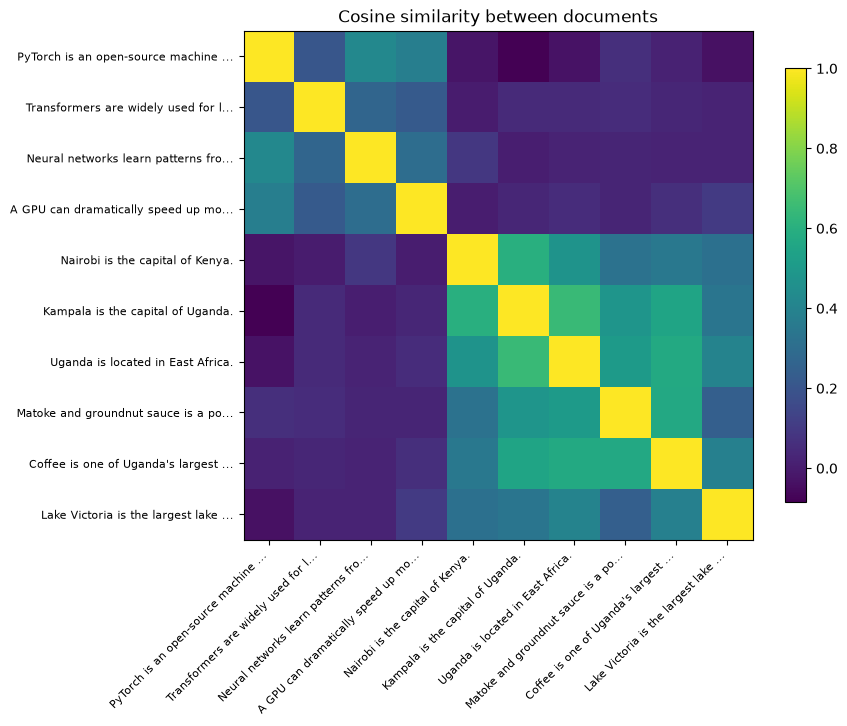

In [13]:
import matplotlib.pyplot as plt

sim_matrix = (doc_embeddings @ doc_embeddings.T).cpu().numpy()

labels = [d[:34] + "..." if len(d) > 34 else d for d in documents]

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(sim_matrix, cmap="viridis")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Cosine similarity between documents")

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

The bright block in the top-left is the "machine learning" cluster. The bright block
in the bottom-right is the "East Africa" cluster. **Nobody labelled these** — the
structure comes entirely from the pretrained model.

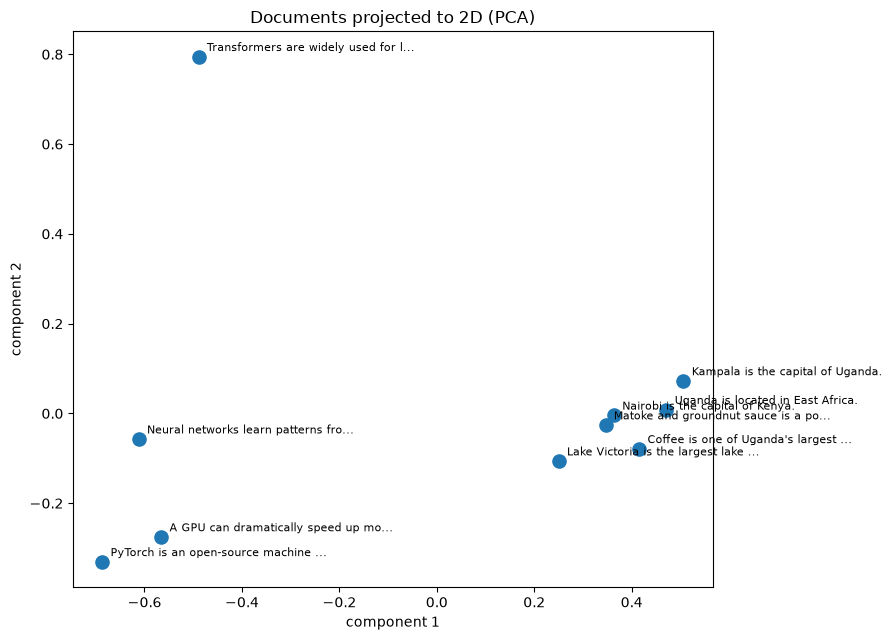

In [14]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2).fit_transform(doc_embeddings.cpu().numpy())

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(coords[:, 0], coords[:, 1], s=90)

for (x, y), label in zip(coords, labels):
    ax.annotate(label, (x, y), fontsize=8, xytext=(6, 4), textcoords="offset points")

ax.set_title("Documents projected to 2D (PCA)")
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
plt.tight_layout()
plt.show()

---
## 7. From retrieval to a tiny RAG system

We now have the **R** in RAG. Adding the **G** means feeding the retrieved documents
to a generative model as context.

```
Question -> retrieve top-k documents -> build a prompt -> LLM -> answer
```

We use `flan-t5-small` (~80M parameters). It is weak compared to a frontier model,
but it downloads in seconds, needs no API key, and makes the mechanism obvious.

In [22]:
from transformers import AutoModelForSeq2SeqLM

GEN_MODEL_NAME = "google/flan-t5-base"   # use "-small" if bandwidth is tight

gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL_NAME).to(DEVICE)
gen_model.eval()

print(f"Generator ready: {sum(p.numel() for p in gen_model.parameters()):,} parameters")

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 372.23it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Generator ready: 247,577,856 parameters


In [23]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int = 60) -> str:
    """Run the generative model on a prompt and return decoded text."""
    inputs = gen_tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=512
    ).to(DEVICE)

    output_ids = gen_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,          # deterministic — same answer every rehearsal
    )

    return gen_tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

In [31]:
def build_prompt(question: str, context_docs: list[str]) -> str:
    """Compose the prompt that is actually sent to the language model."""
    context = "\n".join(f"- {doc}" for doc in context_docs)
    return (
        "Answer the question using only the context below.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )


def ask(question: str, top_k: int = 3, show_prompt: bool = True) -> str:
    """Full RAG loop: retrieve, augment, generate."""
    retrieved = [doc for _, doc in search(question, top_k)]
    prompt = build_prompt(question, retrieved)

    if show_prompt:
        print("--- PROMPT SENT TO THE MODEL ---")
        print(prompt)
        print("--------------------------------")

    answer = generate(prompt, max_new_tokens=60)
    result = print("\nAnswer:", answer)
    return result

In [32]:
ask("What is the capital of Uganda?")

--- PROMPT SENT TO THE MODEL ---
Answer the question using only the context below.

Context:
- Kampala is the capital of Uganda.
- Uganda is located in East Africa.
- Nairobi is the capital of Kenya.

Question: What is the capital of Uganda?
Answer:
--------------------------------

Answer: Kampala


In [33]:
ask("Which framework is open source for machine learning?")

--- PROMPT SENT TO THE MODEL ---
Answer the question using only the context below.

Context:
- PyTorch is an open-source machine learning framework.
- Neural networks learn patterns from data.
- A GPU can dramatically speed up model training.

Question: Which framework is open source for machine learning?
Answer:
--------------------------------

Answer: PyTorch


### The point of this section

Stop and show the prompt. The audience should see that **the LLM was never trained on
our documents** — it simply read them in the prompt.

That is all RAG is:

```
                    +---------------+
                    |   Documents   |
                    +-------+-------+
                            |
                     Embedding model      <- section 3 & 4
                            |
                            v
                     Vector store          <- our tensor of shape (10, 384)
                            ^
                            |
User question -> Embedding -> Search        <- section 5
                            |
                            v
                    Relevant chunks
                            |
                            v
                           LLM             <- section 7
                            |
                            v
                         Answer
```

Everything else — Chroma, FAISS, LangChain, chunking strategies, rerankers — is
engineering around this core.

### One honest caveat to mention

Ask something the documents do not cover and watch what happens:

In [34]:
ask("Who won the 2018 football World Cup?")

--- PROMPT SENT TO THE MODEL ---
Answer the question using only the context below.

Context:
- Lake Victoria is the largest lake in Africa.
- Uganda is located in East Africa.
- Kampala is the capital of Uganda.

Question: Who won the 2018 football World Cup?
Answer:
--------------------------------

Answer: Uganda


In [38]:
MIN_SCORE = 0.30

def ask(question: str, top_k: int = 3, min_score: float = MIN_SCORE,
        show_prompt: bool = True) -> str:
    """Full RAG loop with a relevance gate: retrieve, filter, augment, generate."""
    hits = [(score, doc) for score, doc in search(question, top_k) if score >= min_score]

    if not hits:
        print("Answer: I don't have information about that.")
        return "I don't have information about that."

    prompt = build_prompt(question, [doc for _, doc in hits])
    ...

In [39]:
ask("Who won the 2018 football World Cup?")

Answer: I don't have information about that.


"I don't have information about that."

Retrieval always returns *something* — the top-k nearest documents, however far away
they are. A production system adds a similarity threshold and lets the model say
"I don't know". Worth saying out loud, because this is the #1 surprise for people
building their first RAG app.

---
## 8. Bonus: modern PyTorch — `torch.compile`

`torch.compile` optimizes execution with a one-line change:

```
torch.compile -> TorchDynamo -> FX graph -> TorchInductor -> optimized kernels
```

The first call is **slower** because compilation happens then. Real speedups need a
modern NVIDIA GPU, so treat any number below as a demo, not a promise.

In [35]:
import time


def benchmark(fn, n_runs: int = 20) -> float:
    """Average seconds per call, after a warm-up."""
    for _ in range(3):
        fn()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(n_runs):
        fn()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    return (time.perf_counter() - start) / n_runs


sample = tokenizer(documents, padding=True, truncation=True, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    eager_time = benchmark(lambda: model(**sample))
print(f"Eager          : {eager_time * 1000:.2f} ms / batch")

try:
    compiled_model = torch.compile(model)
    with torch.no_grad():
        compiled_time = benchmark(lambda: compiled_model(**sample))
    print(f"torch.compile  : {compiled_time * 1000:.2f} ms / batch")
    print(f"Speedup        : {eager_time / compiled_time:.2f}x")
except Exception as exc:                       # backend issues are common in Colab
    print("torch.compile unavailable in this runtime:", type(exc).__name__, exc)
    print("Not a problem — everything above still works.")

Eager          : 54.62 ms / batch
torch.compile  : 45.93 ms / batch
Speedup        : 1.19x


---

**Resources**

- PyTorch tutorials: https://pytorch.org/tutorials/
- Hugging Face course: https://huggingface.co/learn
- `torch.compile` guide: https://pytorch.org/tutorials/intermediate/torch_compile_tutorial.html
- MTEB leaderboard (pick an embedding model): https://huggingface.co/spaces/mteb/leaderboard

**Today you used:** tensors, `nn.Module`, tokenizers, a pretrained Transformer,
`torch.no_grad()`, mean pooling, `F.normalize`, `F.cosine_similarity`, `torch.topk`,
and `torch.compile`.